In [4]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, pipeline, set_seed
)
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

dataset = load_dataset('emotion')
label_names = dataset['train'].features['label'].names
print(f"Train size: {len(dataset['train'])}")
print(f"Validation size: {len(dataset['validation'])}")
print(f"Test size: {len(dataset['test'])}")
print(f"Classes: {label_names}")

print("\nData examples:")
for i in range(3):
    sample = dataset['train'][i]
    print(f"[{label_names[sample['label']]}] {sample['text']}")

print("\nTask description: Multi-class classification of short English tweets into 6 emotion categories: sadness, joy, love, anger, fear, surprise.")

model_name = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_name)
demo_texts = [dataset['train'][i]['text'] for i in range(3)]

print("\nTokenization examples:")
for txt in demo_texts:
    enc = tokenizer(txt, truncation=True, padding='max_length', max_length=64)
    print(f"\nText: {txt}")
    print(f"Tokens: {tokenizer.convert_ids_to_tokens(enc['input_ids'])}")
    print(f"Input IDs: {enc['input_ids'][:12]}...")
    print(f"Attention Mask: {enc['attention_mask'][:12]}...")
print(f"\nSpecial tokens: CLS={tokenizer.cls_token_id}, PAD={tokenizer.pad_token_id}, SEP={tokenizer.sep_token_id}")
print("Padding and truncation are applied to max_length=64. Shorter texts are padded with PAD token (attention_mask=0), longer texts are truncated.")

pretrained_model = 'j-hartmann/emotion-english-distilroberta-base'
classifier = pipeline('text-classification', model=pretrained_model, device=0 if torch.cuda.is_available() else -1)
test_texts = [
    "I am so happy today!",
    "This is terrible news, I'm devastated.",
    "I really miss you and hope to see you soon."
]
results = classifier(test_texts)
print("\nPretrained model inference:")
for txt, res in zip(test_texts, results):
    print(f"Text: {txt} -> {res['label']} (score: {res['score']:.3f})")
print("\nNote: The pretrained model captures general emotional cues well but may not align perfectly with the specific label distribution and domain nuances of the emotion dataset. Fine-tuning is required for optimal accuracy.")

def tokenize_function(examples):
    return tokenizer(examples['text'], truncation=True, padding='max_length', max_length=64)

tokenized_datasets = dataset.map(tokenize_function, batched=True, remove_columns=['text'])
tokenized_datasets = tokenized_datasets.rename_column('label', 'labels')
tokenized_datasets.set_format('torch')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='macro')
    return {'accuracy': acc, 'f1_macro': f1}

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=6, ignore_mismatched_sizes=True).to(device)
training_args = TrainingArguments(
    output_dir='./checkpoints',
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    logging_steps=50,
    seed=SEED,
    report_to='none'
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    compute_metrics=compute_metrics
)

print("\nStarting training...")
trainer.train()
print("Training complete. Best model selected by validation f1_macro.")



Device: cuda
Train size: 16000
Validation size: 2000
Test size: 2000
Classes: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

Data examples:
[sadness] i didnt feel humiliated
[sadness] i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
[anger] im grabbing a minute to post i feel greedy wrong

Task description: Multi-class classification of short English tweets into 6 emotion categories: sadness, joy, love, anger, fear, surprise.

Tokenization examples:

Text: i didnt feel humiliated
Tokens: ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]'

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Pretrained model inference:
Text: I am so happy today! -> joy (score: 0.962)
Text: This is terrible news, I'm devastated. -> sadness (score: 0.947)
Text: I really miss you and hope to see you soon. -> sadness (score: 0.981)

Note: The pretrained model captures general emotional cues well but may not align perfectly with the specific label distribution and domain nuances of the emotion dataset. Fine-tuning is required for optimal accuracy.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Training complete. Best model selected by validation f1_macro.



Final test evaluation:


Test Accuracy: 0.9235
Test F1 Macro: 0.8808


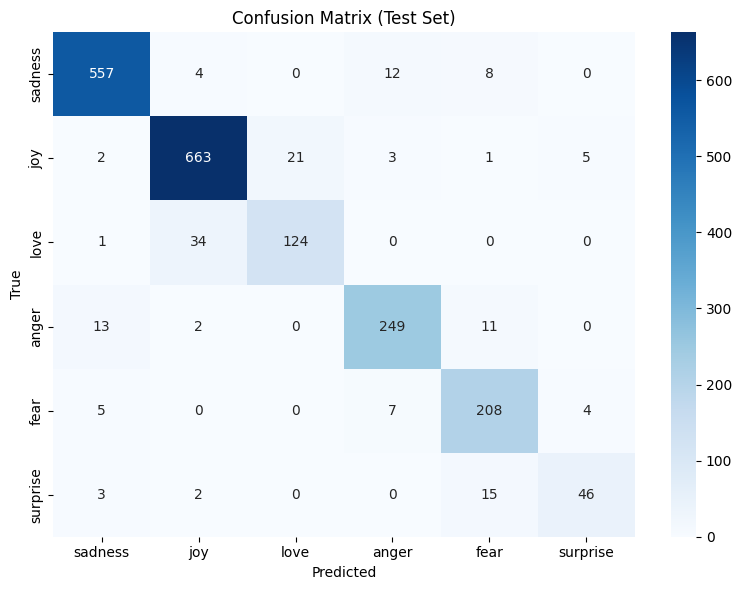

In [5]:
os.makedirs('artifacts', exist_ok=True)
print("\nFinal test evaluation:")
test_results = trainer.evaluate(tokenized_datasets['test'])
test_acc = test_results['eval_accuracy']
test_f1 = test_results['eval_f1_macro']
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1 Macro: {test_f1:.4f}")

test_preds = trainer.predict(tokenized_datasets['test'])
preds = np.argmax(test_preds.predictions, axis=-1)
true_labels = test_preds.label_ids
logits = test_preds.predictions

cm = confusion_matrix(true_labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.savefig('artifacts/confusion_matrix.png', dpi=150)
plt.show()

rng = np.random.RandomState(SEED)
sample_idx = rng.choice(len(true_labels), size=10, replace=False).tolist()
probs = F.softmax(torch.tensor(logits), dim=-1).numpy()



In [6]:
sample_df = pd.DataFrame({
    'text': [dataset['test'][i]['text'] for i in sample_idx],
    'true_label': [label_names[l] for l in true_labels[sample_idx]],
    'pred_label': [label_names[p] for p in preds[sample_idx]],
    'confidence': [probs[i, p] for i, p in zip(sample_idx, preds[sample_idx])]
})
sample_df.to_csv('artifacts/sample_predictions.csv', index=False, index_label=False)
print("\nSample predictions:")
print(sample_df.to_string(index=False))

print("\nError analysis:")
errors = []
for i in range(len(true_labels)):
    if true_labels[i] != preds[i]:
        errors.append({
            'text': dataset['test'][i]['text'],
            'true': label_names[true_labels[i]],
            'pred': label_names[preds[i]],
            'conf': probs[i, preds[i]]
        })
for err in errors[:5]:
    print(f"Text: {err['text']}")
    print(f"True: {err['true']} | Pred: {err['pred']} | Conf: {err['conf']:.3f}\n")
print("Summary: The model frequently confuses semantically close emotions such as joy/love and sadness/anger. Short tweet length and overlapping lexical markers contribute to these boundary cases.")
print("Artifacts saved: artifacts/confusion_matrix.png, artifacts/sample_predictions.csv")


Sample predictions:
                                                                                                                                                                                                                                          text true_label pred_label  confidence
i feel so dirty but after spending a day at the mk show me and a buddy decided we would get the two player starter between us luckily for us both i liked the everblight and he liked the circle maybe a tad to much so it all worked out well    sadness    sadness    0.996719
                                                                                                                                                                                i could feel his breath on me and smell the sweet scent of him        joy       love    0.850102
                                                                                                                                                                